In [1]:
!python --version

Python 3.13.2


In [2]:
#importing necessary modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
#from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import seaborn as sns
import copairs
import pycytominer
from copairs.map import average_precision
from copairs.map import mean_average_precision
from utils import * 

%load_ext autoreload
%autoreload 2

/opt/anaconda3/envs/copairs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pip show copairs

Name: copairs
Version: 0.5.1
Summary: Find pairs and compute metrics between them
Home-page: https://github.com/cytomining/copairs
Author: 
Author-email: John Arevalo <johnarevalo@gmail.com>, Alexandr Kalinin <akalinin@broadinstitute.org>, "Alan F. Munoz" <amunozgo@broadinstitute.org>
License: 
Location: /opt/anaconda3/envs/copairs/lib/python3.13/site-packages
Requires: duckdb, pandas, statsmodels, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
#Reading the normalized and feature selected files for copairs - fixed cells and 48h time point
profiles = {'/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122250_normalized_feature_select_negcon_batch.csv':'Standard CP',
                                 '/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122246_normalized_feature_select_negcon_batch.csv':'CP + MitoBrilliant',
                                 '/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122247_normalized_feature_select_negcon_batch.csv':'CP + Phenovue phalloidin 400LS',
                                 '/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122248_normalized_feature_select_negcon_batch.csv':'Standard CP (exposed to ChromaLive)',
                                 '/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122249_normalized_feature_select_negcon_batch_wo_phasefeatures.csv':'ChromaLive + Hoechst'

}


In [25]:
def cell_counts(input_dict={}):
     
    combined_df = pd.DataFrame()

    for i in input_dict:
            
            with open(i, 'rb') as filetype:
                if filetype.read(2) == b'\x1f\x8b':
                    df = pd.read_csv(i, compression='gzip')
                else:
                    df = pd.read_csv(i)
            subset_df = df[['Metadata_Count_Cells']]
            subset_df = subset_df.rename(columns={'Metadata_Count_Cells': input_dict[i]})
            combined_df = pd.concat([combined_df, subset_df], axis=1)
    combined_df = pd.concat([combined_df, df['Metadata_Well']], axis=1)

    return combined_df


In [41]:
cell_count_df = cell_counts(profiles)

In [42]:
cell_count_df

,Standard CP,CP + MitoBrilliant,CP + Phenovue phalloidin 400LS,Standard CP (exposed to ChromaLive),ChromaLive + Hoechst,Metadata_Well
0,3121,3456.0,3361,3093,3219,A01
1,3804,4102.0,4012,3539,3824,A02
2,3766,3903.0,4048,3567,3838,A03
3,2922,3304.0,3239,2711,2768,A04
4,3971,4045.0,3955,3502,3722,A05
...,...,...,...,...,...,...
379,4017,3614.0,3836,3428,3445,P20
380,3634,3995.0,3505,3094,3593,P21
381,3835,4099.0,3974,3041,3752,P22
382,4043,3411.0,4048,3336,3628,P23


In [44]:
cell_count_df.to_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/cell_counts.csv', index=False)

### Cell count csv for plate 46 since one of the wells misses the cell count data because of the corrupt images from a single well

In [ ]:
plate46_data = pd.read_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/BR00122246_normalized_feature_select_negcon_batch.csv', compression='gzip')
plate46_data_df = plate46_data[['Metadata_Well', 'Metadata_Count_Cells']]
plate46_data_df = plate46_data_df.rename(columns={'Metadata_Count_Cells': 'CP + MitoBrilliant'})
plate46_data_df
plate46_data_df.to_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/cell_counts_plate46.csv', index=False)

### Combining the plate46 with all the other plates

In [ ]:
cell_count_df = cell_count_df.drop(columns=['CP + MitoBrilliant'])
all_df = pd.merge(cell_count_df, plate46_data_df, on='Metadata_Well', how='outer')

In [118]:
all_df

,Standard CP,CP + Phenovue phalloidin 400LS,Standard CP (exposed to ChromaLive),ChromaLive + Hoechst,Metadata_Well,CP + MitoBrilliant
0,3121,3361,3093,3219,A01,3456.0
1,3804,4012,3539,3824,A02,4102.0
2,3766,4048,3567,3838,A03,3903.0
3,2922,3239,2711,2768,A04,3304.0
4,3971,3955,3502,3722,A05,4045.0
...,...,...,...,...,...,...
379,4017,3836,3428,3445,P20,3899.0
380,3634,3505,3094,3593,P21,3614.0
381,3835,3974,3041,3752,P22,3995.0
382,4043,4048,3336,3628,P23,4099.0


In [119]:
all_df.to_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/cell_counts_all.csv', index=False)

### Standard CP

In [28]:
cell_count_df['Standard CP'].min()

np.int64(58)

In [30]:
cell_count_df['Standard CP'].max()

np.int64(4746)

### CP + MitoBrilliant

In [ ]:
cell_count_df['CP + MitoBrilliant'].min()

np.float64(42.0)

In [33]:
cell_count_df['CP + MitoBrilliant'].max()

np.float64(4882.0)

### CP + Phenovue phalloidin 400LS

In [34]:
cell_count_df['CP + Phenovue phalloidin 400LS'].min()

np.int64(40)

In [35]:
cell_count_df['CP + Phenovue phalloidin 400LS'].max()

np.int64(4624)

### Standard CP (exposed to ChromaLive)	

In [36]:
cell_count_df['Standard CP (exposed to ChromaLive)'].min()

np.int64(84)

In [37]:
cell_count_df['Standard CP (exposed to ChromaLive)'].max()

np.int64(4529)

### ChromaLive + Hoechst

In [38]:
cell_count_df['ChromaLive + Hoechst'].min()

np.int64(236)

In [39]:
cell_count_df['ChromaLive + Hoechst'].max()

np.int64(4791)

### Making plots 

In [ ]:
import string
import seaborn as sns
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


In [108]:
def cell_count_plot(column_name =''):
    # Read CSV
    df = pd.read_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/cell_counts.csv')
    df = df.fillna('null')

    # Choose a column
    column = column_name  
    data_array = np.array(df[column])


    # Reshape to 16×24
    plate_data = data_array.reshape((16, 24))

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))

    
    cmap = cm.get_cmap('cividis')  
    norm = mcolors.Normalize(vmin=0, vmax=5000)

    
    heatmap = ax.imshow(plate_data, cmap=cmap, norm=norm, aspect='equal')

    # Draw well values on top
    for row in range(16):
        for col in range(24):
            val = plate_data[row, col]
            if not np.isnan(val):
                ax.text(col, row, f"{int(val)}", ha='center', va='center', fontsize=8, color='white')

  
    ax.set_xticks(np.arange(24))
    ax.set_yticks(np.arange(16))
    ax.set_xticklabels(np.arange(1, 25))
    ax.set_yticklabels(list(string.ascii_uppercase[:16]))
    ax.xaxis.tick_top()
    ax.tick_params(length=0)

    # Grid 
    for x in range(25):
        ax.axvline(x - 0.5, color='black', linewidth=0.5)
    for y in range(17):
        ax.axhline(y - 0.5, color='black', linewidth=0.5)

    
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(15.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f"{column}", pad=15)

   
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label('Cell Count')

    plt.tight_layout()
    plt.show()

/var/folders/mc/vhp8_f3x2mxgzyb5s3xbtwzh0000gn/T/ipykernel_18397/2783211364.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')


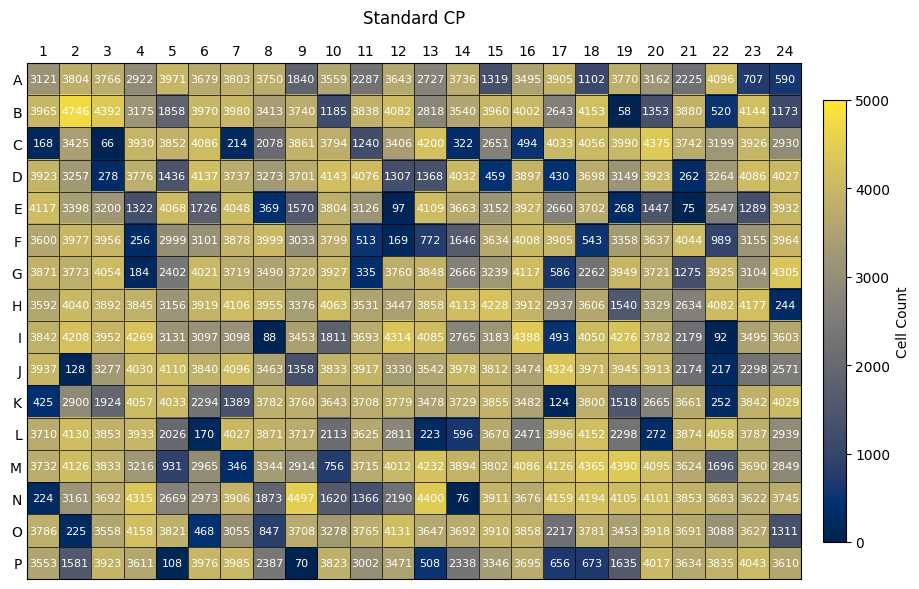

In [109]:
cell_count_plot('Standard CP')

/var/folders/mc/vhp8_f3x2mxgzyb5s3xbtwzh0000gn/T/ipykernel_18397/2783211364.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')


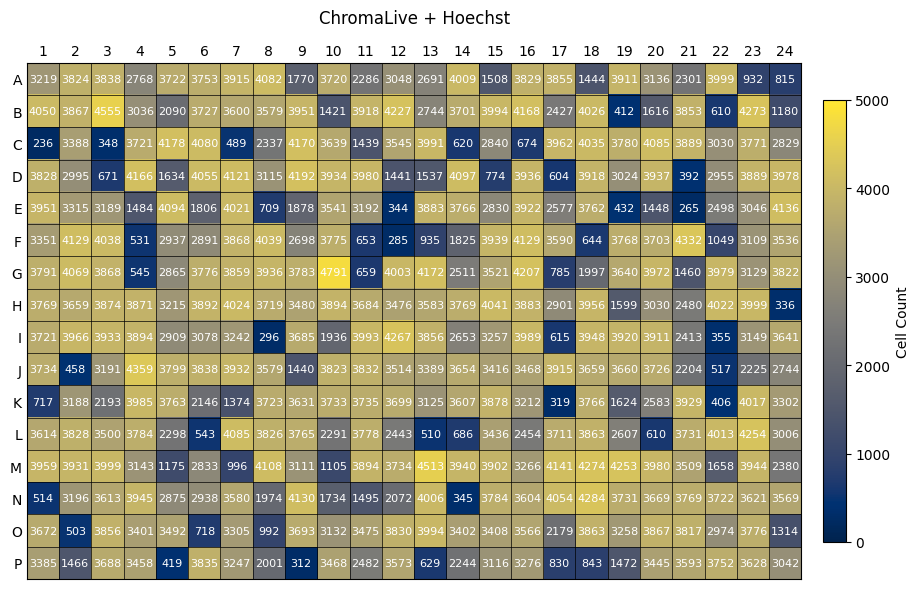

In [110]:
cell_count_plot('ChromaLive + Hoechst')

/var/folders/mc/vhp8_f3x2mxgzyb5s3xbtwzh0000gn/T/ipykernel_18397/2783211364.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')


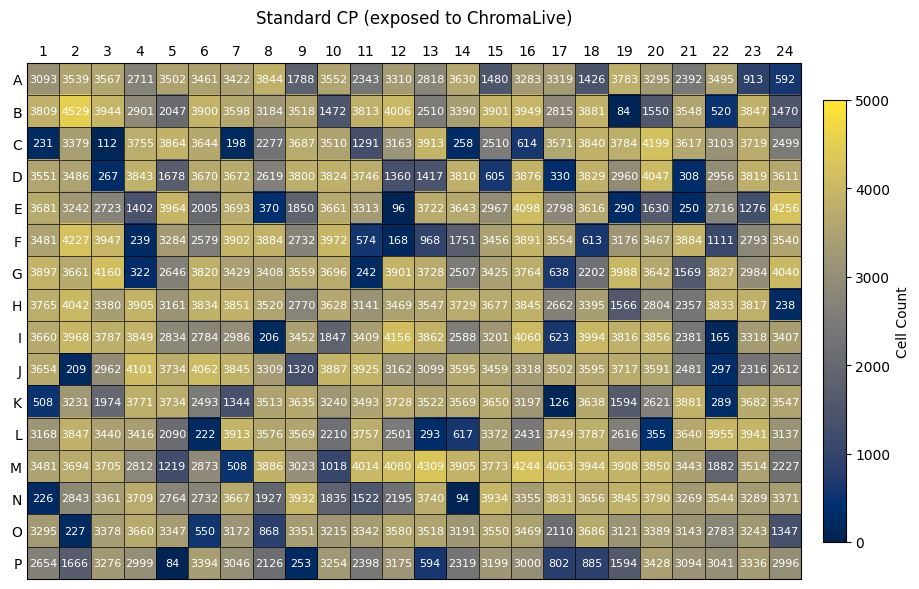

In [111]:
cell_count_plot('Standard CP (exposed to ChromaLive)')

/var/folders/mc/vhp8_f3x2mxgzyb5s3xbtwzh0000gn/T/ipykernel_18397/2783211364.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')


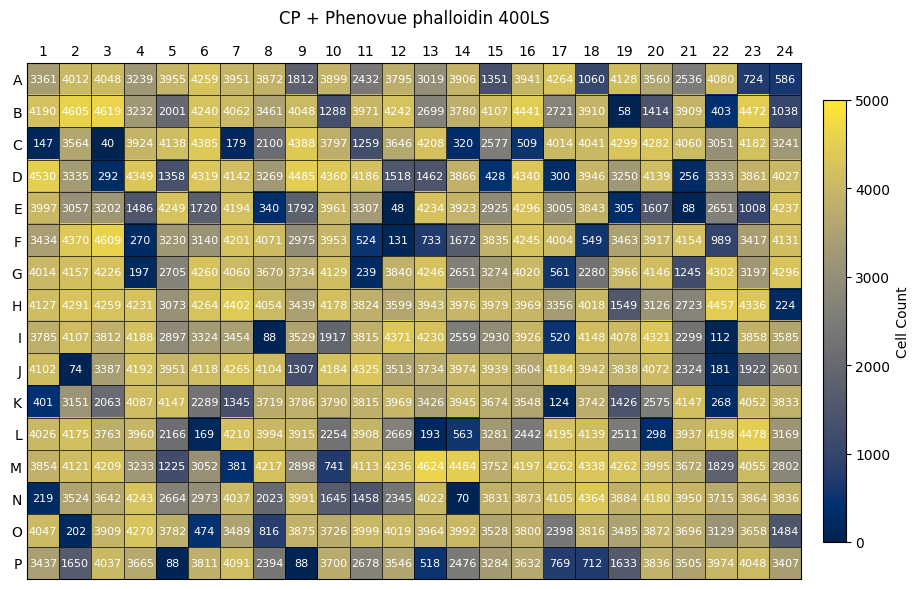

In [112]:
cell_count_plot('CP + Phenovue phalloidin 400LS')

### Since one of the wells misses the cell count data because of the corrupt images from a single well in plate 46, the code is modified to handle missing data


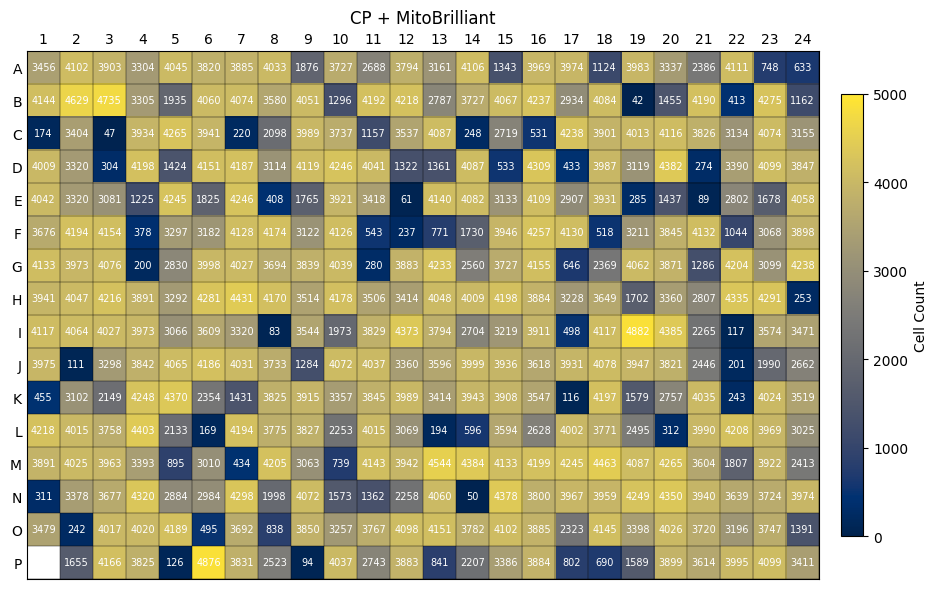

In [113]:
# Load CSV
df = pd.read_csv('/Users/sugan/Documents/GitHub/2022_09_07_New_phenotypic_dye_testing_CDoT_Broad_Analysis/copairs_csv/UpdatedCopairsVersion/cell_counts_plate46.csv')
df = df.fillna('null')

# Define well layout
rows = list(string.ascii_uppercase[:16])   # A–P
cols = [f"{i:02d}" for i in range(1, 25)]  # 01–24
all_wells = [r + c for r in rows for c in cols]

# Your column names
well_col = 'Metadata_Well'                 # Column with A01, B02, etc.
value_col = 'CP + MitoBrilliant'  # Column with numeric cell counts

# Make a dict for quick lookup
value_dict = dict(zip(df[well_col], df[value_col]))

# Fill plate matrix with counts or NaN for missing wells
plate_data = np.array([value_dict.get(well, np.nan) for well in all_wells], dtype=float).reshape(16, 24)

# Start plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot heatmap background using imshow
cmap = cm.cividis
norm = mcolors.Normalize(vmin=0, vmax=5000)
heatmap = ax.imshow(plate_data, cmap=cmap, norm=norm, aspect='equal')


for row in range(16):
    for col in range(24):
        val = plate_data[row, col]
        if not np.isnan(val):
            ax.text(col, row, f"{int(val)}", ha='center', va='center', fontsize=7, color='white')

# Axes setup
ax.set_xticks(np.arange(24))
ax.set_yticks(np.arange(16))
ax.set_xticklabels(np.arange(1, 25))
ax.set_yticklabels(rows)
ax.xaxis.tick_top()
ax.tick_params(length=0)

# Grid
for x in range(25):
    ax.axvline(x - 0.5, color='black', linewidth=0.3)
for y in range(17):
    ax.axhline(y - 0.5, color='black', linewidth=0.3)


ax.set_xlim(-0.5, 23.5)
ax.set_ylim(15.5, -0.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f"{value_col}", pad=20)


cbar = plt.colorbar(heatmap, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Cell Count')

plt.tight_layout()
plt.show()